# 03 - Pose Estimation

Ejemplos para modelos de pose. Los keypoints quedan como listas `[[x, y, score], ...]` dentro del `DataFrame` y se pueden plotear directamente sobre la imagen.


In [1]:
import os
import pandas as pd
from vision.yolo.infer import predict_image
from vision.yolo.plotting import plot_pose_keypoints, plot_image_detections

IMAGE = "input/elevate-nYgy58eb9aw-unsplash.jpg"
MODEL = "yolo11s-pose.pt"



In [2]:
df = predict_image(MODEL, IMAGE, confidence=0.25, task="pose", imgsz=320)
print(
    df[
        [
            "frame",
            "class_name",
            "confidence",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "keypoints",
        ]
    ].head()
)


/home/juan/miniforge3/envs/ultralytics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


   frame class_name  confidence         xmin        ymin         xmax  \
0      0     person    0.920786     0.284469  420.410278   748.767517   
1      0     person    0.906363  1595.694580  456.964081  2426.565430   
2      0     person    0.905633   800.340759  691.301697  1497.809570   
3      0     person    0.685633  2194.370361  321.393768  3036.000000   

          ymax                                          keypoints  
0  2150.685547  [[611.0728149414062, 587.322509765625, 0.97717...  
1  2151.364502  [[1836.2674560546875, 687.9857788085938, 0.957...  
2  2152.293213  [[1200.3978271484375, 863.4613647460938, 0.985...  
3  2149.177734  [[2520.623046875, 654.2954711914062, 0.7376007...  


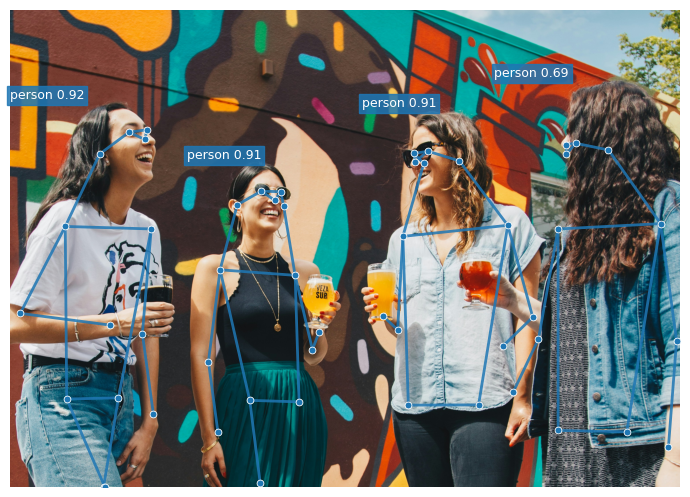

In [4]:
# Plot directo de skeleton + cajas

saved_image_name = "outputs/03_pose_detections.png"

plot_pose_keypoints(
    IMAGE,
    df,
    keypoint_threshold=0.25,
    figsize=(7, 6),
    draw_boxes=False
)


In [5]:
# Convertir keypoints a formato largo para analisis tabular
rows = []
for det_idx, row in df.iterrows():
    keypoints = row.get("keypoints")
    if not isinstance(keypoints, list):
        continue
    for kp_idx, kp in enumerate(keypoints):
        if len(kp) >= 3:
            x, y, score = kp[:3]
        else:
            x, y = kp[:2]
            score = 1.0
        rows.append(
            {
                "detection": det_idx,
                "class_name": row["class_name"],
                "keypoint": kp_idx,
                "x": x,
                "y": y,
                "score": score,
            }
        )
keypoints_long = pd.DataFrame(rows)
print(keypoints_long.head())


   detection class_name  keypoint           x           y     score
0          0     person         0  611.072815  587.322510  0.977179
1          0     person         1  620.421082  543.178162  0.750715
2          0     person         2  538.958069  554.546631  0.970821
3          0     person         3  603.930725  620.172668  0.191686
4          0     person         4  406.155182  653.343750  0.960921
